In [1]:
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
from tqdm import tqdm

from phd_helpers.paths import get_task_stl_paths, get_mesh, avg_edge_length, get_info
from phd_helpers.MeshQuality import compute_d_metrics, compute_dists, compute_mesh_metrics, compute_rmsd, sample_surface

In [14]:
from phd_helpers.paths import get_info_df, get_subject_stl_path
info = get_info_df()
info = info[info['group']=='CMC']
info.tpm_volume.mean()

avg_tpm = get_mesh(get_subject_stl_path('15285', 'R'), 'tpm')
avg_mc1 = get_mesh(get_subject_stl_path('15285', 'R'), 'mc1')

print('tpm V:', avg_tpm.volume)
print('mc1 V:', avg_mc1.volume)

print('tpm A:', avg_tpm.area)
print('mc1 A:', avg_mc1.area)

tpm V: 2009.0932514622593
mc1 V: 5570.807004833923
tpm A: 944.1480229880412
mc1 A: 2138.4325378429235


Bone with average volume ~ 2000mm^3 has area ~1000mm^2 so sampling 100000 points gives ~100 / mm^2

In [8]:
n_samples = 100000
bones = ['tpm', 'mc1']
stl_paths = get_task_stl_paths('CMC')
n_iters = np.hstack( (np.arange(0, 110, 10), np.arange(150, 550, 50)) )

data = []
for sp in tqdm(stl_paths):
    sub, side = get_info(sp)
    for bone in bones:
        mesh = get_mesh(sp, bone)
        for n_iter in n_iters:  
            if n_iter > 0: mesh_smooth = mesh.smooth_taubin(n_iter=n_iter)
            else: mesh_smooth = mesh.copy(deep=True)

            mesh2smooth = compute_dists(sample_surface(mesh, n_samples), mesh_smooth)
            smooth2mesh = compute_dists(sample_surface(mesh_smooth, n_samples), mesh)
            d = np.hstack( (mesh2smooth, smooth2mesh) )

            mets = {
                'sub': f'{sub}{side}',
                'bone': bone,
                'n_iter': n_iter,
                'rmsd': compute_rmsd(d)
            }
            # distance
            mets = compute_d_metrics(d, mets, 'd_')
            # curve
            #mets = compute_curv_metrics(mesh, mets, True, True, False, False, 'orig_')
            #mets = compute_curv_metrics(mesh_smooth, mets, True, True, False, False, 'smooth_')
            # surface
            mets = compute_mesh_metrics(mesh, mets, vol=True, edge_length=True, label='orig_')
            mets = compute_mesh_metrics(mesh_smooth, mets, vol=True, edge_length=True, label='smooth_')

            data.append(mets)
pd.DataFrame(data).to_csv('outputs-redo/smoothTaubin-redo.csv', index=False)
        

100%|██████████| 46/46 [22:01<00:00, 28.74s/it]


In [9]:
df = pd.read_csv('outputs-redo/smoothTaubin-redo.csv')
df

,sub,bone,n_iter,rmsd,d_mean,d_median,d_std,d_max,d_99,d_95,orig_points,orig_cells,orig_A,orig_V,orig_L_edge,smooth_points,smooth_cells,smooth_A,smooth_V,smooth_L_edge
0,50037L,tpm,0,1.903936e-15,2.545854e-16,0.000000,1.886839e-15,2.009718e-14,1.421085e-14,0.000000,13134,26264,1234.525594,2907.729113,0.368828,13134,26264,1234.525594,2907.729113,0.368828
1,50037L,tpm,10,6.778660e-03,4.553274e-03,0.003033,5.021746e-03,9.078108e-02,2.439045e-02,0.014045,13134,26264,1234.525594,2907.729113,0.368828,13134,26264,1228.579422,2908.215149,0.355190
2,50037L,tpm,20,1.823691e-02,1.262713e-02,0.008806,1.315829e-02,1.866671e-01,6.328390e-02,0.037285,13134,26264,1234.525594,2907.729113,0.368828,13134,26264,1221.041190,2908.980986,0.344821
3,50037L,tpm,30,2.566799e-02,1.828861e-02,0.013233,1.801035e-02,2.691769e-01,8.410698e-02,0.052669,13134,26264,1234.525594,2907.729113,0.368828,13134,26264,1215.951733,2909.170579,0.342330
4,50037L,tpm,40,3.118908e-02,2.259540e-02,0.016683,2.149899e-02,2.707540e-01,9.962363e-02,0.063660,13134,26264,1234.525594,2907.729113,0.368828,13134,26264,1212.745782,2909.149018,0.341215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1743,14685R,mc1,300,3.831517e-02,2.847007e-02,0.021288,2.564191e-02,2.878343e-01,1.164144e-01,0.080158,22432,44860,2049.543458,5329.531954,0.365684,22432,44860,2023.074913,5322.901153,0.343649
1744,14685R,mc1,350,3.885419e-02,2.889557e-02,0.021659,2.597488e-02,2.716712e-01,1.177253e-01,0.081469,22432,44860,2049.543458,5329.531954,0.365684,22432,44860,2022.959644,5322.838502,0.343622
1745,14685R,mc1,400,3.942602e-02,2.926862e-02,0.021878,2.641513e-02,2.822235e-01,1.204762e-01,0.082674,22432,44860,2049.543458,5329.531954,0.365684,22432,44860,2022.837415,5322.763858,0.343596
1746,14685R,mc1,450,3.962341e-02,2.952203e-02,0.022196,2.642847e-02,2.767615e-01,1.195129e-01,0.083121,22432,44860,2049.543458,5329.531954,0.365684,22432,44860,2022.741546,5322.703028,0.343577


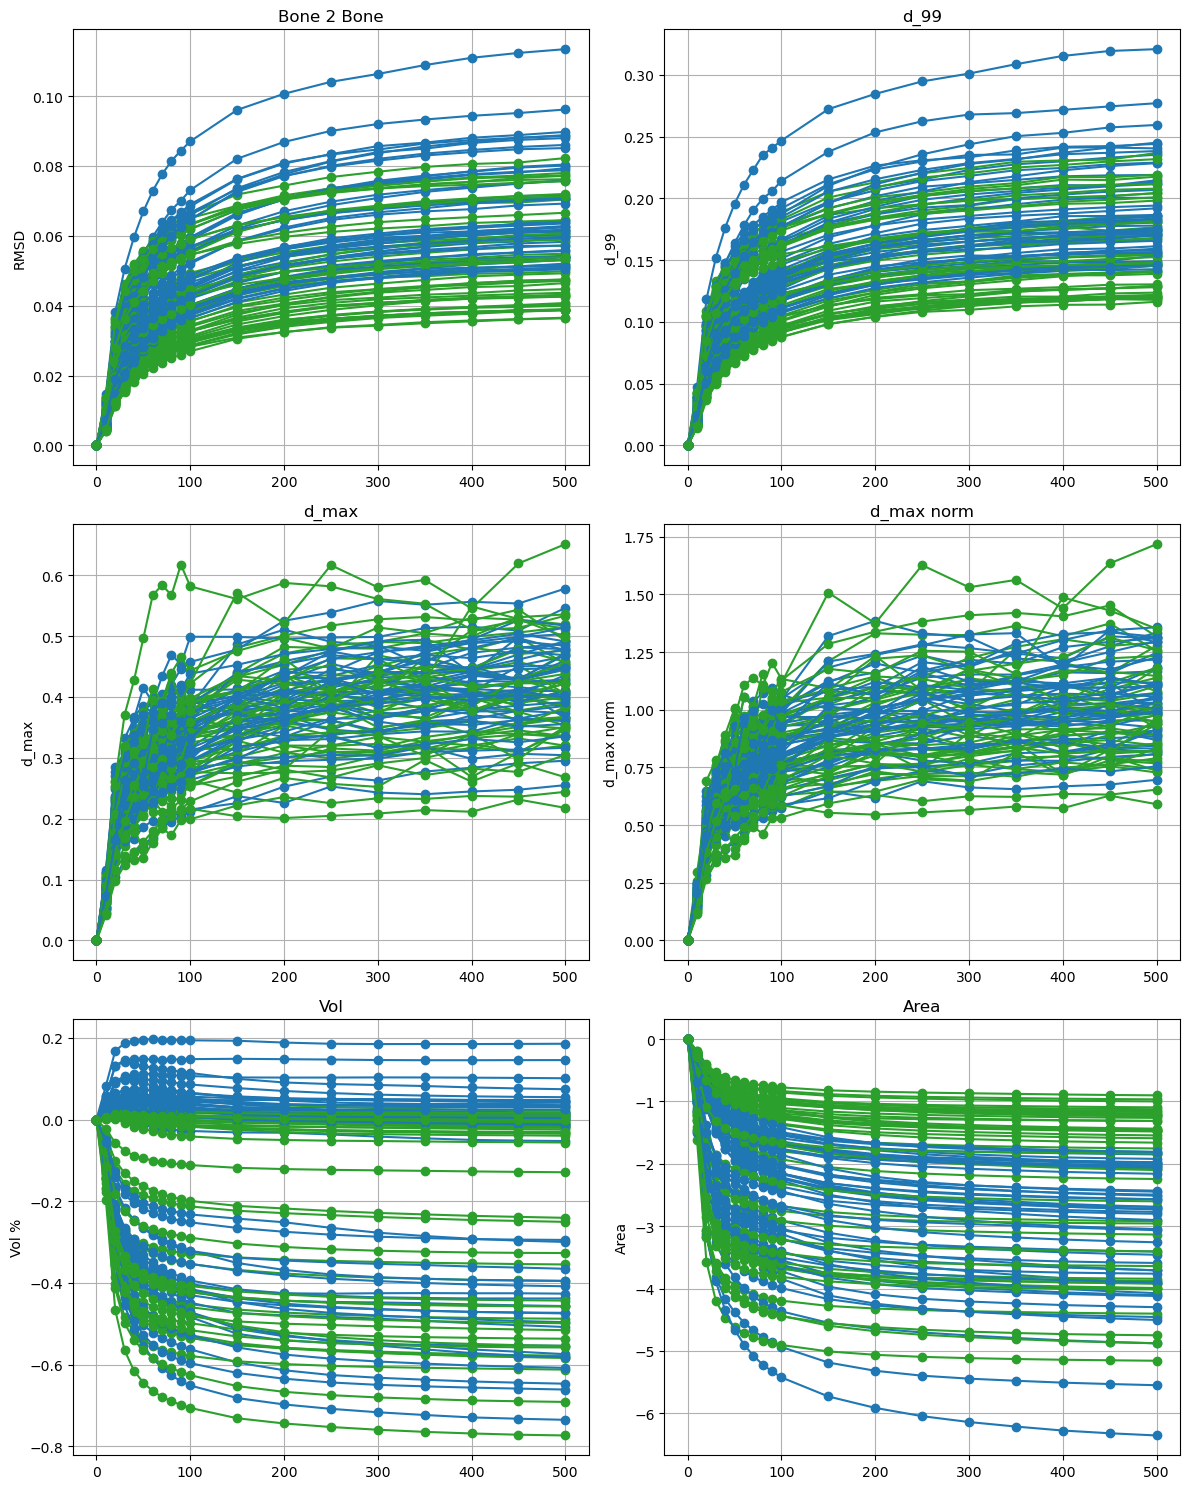

In [10]:
# somtimes there are holes on edge of mesh where a cell should be or was in previous mesh
# max distance field 2 field can be affected by one point lying in one of the empty channels that form in the field

import matplotlib.pyplot as plt

bones = ['tpm', 'mc1']
subs_sides = df['sub'].unique()
x = df['n_iter'].unique()

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

c_map = {
    'tpm': 'tab:blue',
    'mc1': 'tab:green'
}

for sub in subs_sides:
    #sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
    for bone in bones:
        sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
        c = c_map[bone]
    #x = sub_df['cells_field'][::-1]

        ax[0].plot(x, sub_df['rmsd'], marker='o', c=c)
        ax[0].set_title('Bone 2 Bone')
        ax[0].set_ylabel('RMSD')

        ax[1].plot(x, sub_df['d_99'], marker='o', c=c)
        ax[1].set_title('d_99')
        ax[1].set_ylabel('d_99')

        ax[2].plot(x, sub_df['d_max'], marker='o', c=c)
        ax[2].set_title('d_max')
        ax[2].set_ylabel('d_max')

        ax[3].plot(x, sub_df['d_max'] / sub_df['orig_L_edge'], marker='o', c=c)
        ax[3].set_title('d_max norm')
        ax[3].set_ylabel('d_max norm')

        ax[4].plot(x, 100* (sub_df['smooth_V'] - sub_df['orig_V']) / sub_df['orig_V'], marker='o', c=c)
        ax[4].set_title('Vol')
        ax[4].set_ylabel('Vol %')

        # area slowly increases as it squeezes out every point up to 2mm
        ax[5].plot(x, 100* (sub_df['smooth_A'] - sub_df['orig_A']) / sub_df['orig_A'], marker='o', c=c)
        ax[5].set_title('Area')
        ax[5].set_ylabel('Area')


for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()